# Urban Traffic Motif Discovery with the Matrix Profile

This unsupervised-learning project discovers recurring traffic-volume patterns in hourly Interstate 94 traffic data.

The analysis uses:

- time-series motif discovery;
- the Matrix Profile;
- STUMPY's STUMP algorithm;
- chronological validation;
- window-length robustness analysis.

The practical objective is to build a library of recurring traffic patterns that could support transport planning, congestion monitoring and operational staffing.

In [1]:
import io
import time
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import stumpy

SEED = 42
sns.set_theme(style="whitegrid")

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


## 1. Dataset

Each row represents traffic volume recorded during one hour at Minnesota Department of Transportation station 301 on westbound Interstate 94.

Important variables include:

- `date_time`: date and hour;
- `traffic_volume`: vehicles recorded during the hour;
- `holiday`: holiday information;
- `temp`: temperature;
- `rain_1h`: hourly rainfall;
- `snow_1h`: hourly snowfall;
- `clouds_all`: cloud coverage;
- `weather_main`: general weather condition.

The original dataset may contain multiple rows for the same timestamp when several weather descriptions were recorded. These duplicate timestamps must be aggregated before creating the time series.

In [2]:
DATA_URL = (
    "https://archive.ics.uci.edu/static/public/492/"
    "metro+interstate+traffic+volume.zip"
)

response = requests.get(DATA_URL, timeout=120)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
    data_name = next(
        name for name in archive.namelist()
        if name.lower().endswith(
            (".csv", ".csv.gz")
        )
    )

    compression = (
        "gzip"
        if data_name.lower().endswith(".gz")
        else None
    )

    with archive.open(data_name) as file:
        raw_df = pd.read_csv(
            file,
            compression=compression
        )

print("Dataset shape:", raw_df.shape)
raw_df.head()

Dataset shape: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [3]:
raw_df["date_time"] = pd.to_datetime(
    raw_df["date_time"]
)

initial_summary = pd.Series({
    "rows": len(raw_df),
    "columns": raw_df.shape[1],
    "missing_values": raw_df.isna().sum().sum(),
    "unique_timestamps":
        raw_df["date_time"].nunique(),
    "duplicate_timestamp_rows":
        len(raw_df)
        - raw_df["date_time"].nunique(),
    "start_date": raw_df["date_time"].min(),
    "end_date": raw_df["date_time"].max()
})

initial_summary

rows                                      48204
columns                                       9
missing_values                            48143
unique_timestamps                         40575
duplicate_timestamp_rows                   7629
start_date                  2012-10-02 09:00:00
end_date                    2018-09-30 23:00:00
dtype: object

In [4]:
def modal_value(values):
    modes = values.mode(dropna=True)

    if len(modes) > 0:
        return modes.iloc[0]

    return np.nan


hourly_observed = (
    raw_df.groupby(
        "date_time",
        as_index=False
    )
    .agg({
        "traffic_volume": "mean",
        "temp": "mean",
        "rain_1h": "max",
        "snow_1h": "max",
        "clouds_all": "mean",
        "holiday": modal_value,
        "weather_main": modal_value
    })
    .sort_values("date_time")
)

print(
    "Rows after timestamp aggregation:",
    len(hourly_observed)
)

hourly_observed.head()

Rows after timestamp aggregation: 40575


,date_time,traffic_volume,temp,rain_1h,snow_1h,clouds_all,holiday,weather_main
0,2012-10-02 09:00:00,5545.0,288.28,0.0,0.0,40.0,NaN,Clouds
1,2012-10-02 10:00:00,4516.0,289.36,0.0,0.0,75.0,NaN,Clouds
2,2012-10-02 11:00:00,4767.0,289.58,0.0,0.0,90.0,NaN,Clouds
3,2012-10-02 12:00:00,5026.0,290.13,0.0,0.0,90.0,NaN,Clouds
4,2012-10-02 13:00:00,4918.0,291.14,0.0,0.0,75.0,NaN,Clouds


In [5]:
full_hourly_index = pd.date_range(
    start=hourly_observed["date_time"].min(),
    end=hourly_observed["date_time"].max(),
    freq="h"
)

hourly = (
    hourly_observed
    .set_index("date_time")
    .reindex(full_hourly_index)
)

hourly.index.name = "date_time"

hourly["was_observed"] = (
    hourly["traffic_volume"].notna()
)

In [6]:
hourly["traffic_volume_clean"] = (
    hourly["traffic_volume"]
    .interpolate(
        method="time",
        limit=3,
        limit_area="inside"
    )
)

hourly["was_short_gap_filled"] = (
    hourly["traffic_volume"].isna()
    & hourly["traffic_volume_clean"].notna()
)

regularity_summary = pd.Series({
    "total_hourly_positions": len(hourly),
    "originally_observed_hours":
        hourly["was_observed"].sum(),
    "short_gap_hours_filled":
        hourly["was_short_gap_filled"].sum(),
    "remaining_missing_hours":
        hourly[
            "traffic_volume_clean"
        ].isna().sum(),
    "observed_percentage":
        100 * hourly["was_observed"].mean()
})

regularity_summary.round(2)

total_hourly_positions       52551.00
originally_observed_hours    40575.00
short_gap_hours_filled        3179.00
remaining_missing_hours       8797.00
observed_percentage             77.21
dtype: float64

In [7]:
ANALYSIS_START = "2016-01-01"

traffic_df = hourly.loc[
    ANALYSIS_START:
].copy()

traffic_df["hour"] = traffic_df.index.hour
traffic_df["day_of_week"] = (
    traffic_df.index.day_name()
)

analysis_summary = pd.Series({
    "analysis_start": traffic_df.index.min(),
    "analysis_end": traffic_df.index.max(),
    "hourly_positions": len(traffic_df),
    "usable_traffic_values":
        traffic_df[
            "traffic_volume_clean"
        ].notna().sum(),
    "remaining_missing_values":
        traffic_df[
            "traffic_volume_clean"
        ].isna().sum()
})

analysis_summary

analysis_start              2016-01-01 00:00:00
analysis_end                2018-09-30 23:00:00
hourly_positions                          24096
usable_traffic_values                     24075
remaining_missing_values                     21
dtype: object

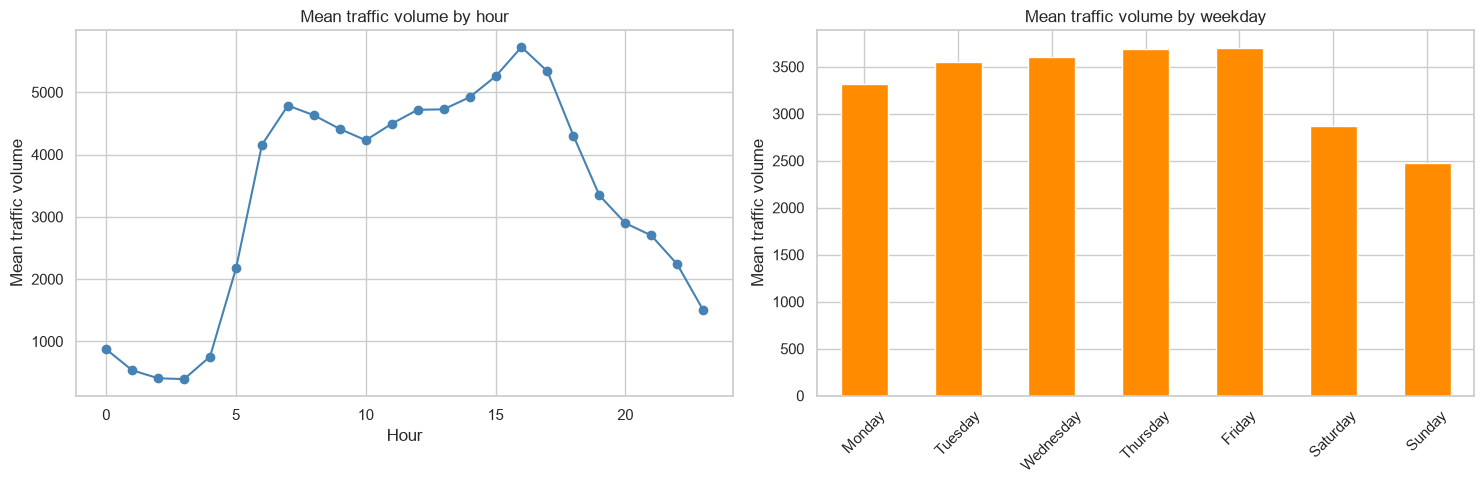

In [8]:
hourly_pattern = (
    traffic_df.groupby("hour")[
        "traffic_volume_clean"
    ]
    .mean()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_pattern = (
    traffic_df.groupby("day_of_week")[
        "traffic_volume_clean"
    ]
    .mean()
    .reindex(day_order)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

hourly_pattern.plot(
    ax=axes[0],
    marker="o",
    color="steelblue"
)

axes[0].set_title(
    "Mean traffic volume by hour"
)
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Mean traffic volume")

weekday_pattern.plot(
    kind="bar",
    ax=axes[1],
    color="darkorange"
)

axes[1].set_title(
    "Mean traffic volume by weekday"
)
axes[1].set_xlabel("")
axes[1].set_ylabel("Mean traffic volume")
axes[1].tick_params(
    axis="x",
    rotation=45
)

plt.tight_layout()
plt.show()

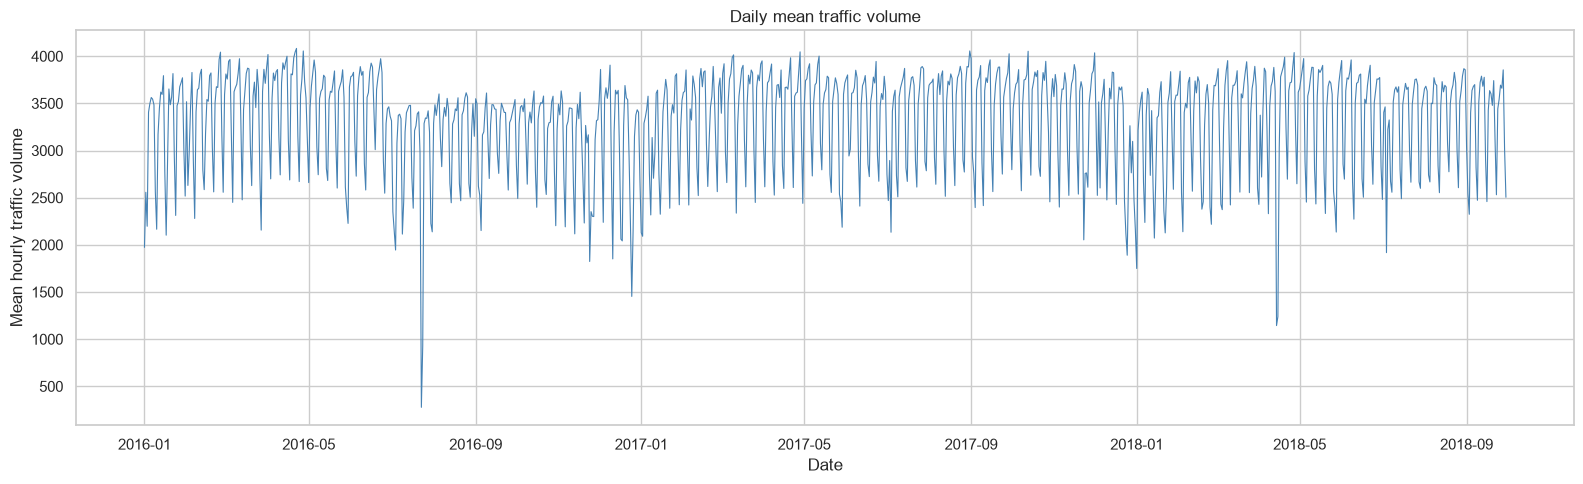

In [9]:
daily_traffic = (
    traffic_df["traffic_volume_clean"]
    .resample("D")
    .mean()
)

plt.figure(figsize=(16, 5))

plt.plot(
    daily_traffic.index,
    daily_traffic,
    color="steelblue",
    linewidth=0.8
)

plt.title("Daily mean traffic volume")
plt.xlabel("Date")
plt.ylabel("Mean hourly traffic volume")
plt.tight_layout()
plt.show()

## Exploratory findings

- Original rows: **48,204**
- Unique timestamps: **40,575**
- Duplicate timestamp rows: **7,629**
- Analysis period: **1 January 2016 to 30 September 2018**
- Hourly positions in the analysis period: **24,096**
- Usable hourly traffic values: **24,075**
- Short-gap hours filled across the complete dataset: **3,179**
- Remaining missing hours across the complete dataset: **8,797**
- Remaining missing hours in the selected analysis period: **21**

The duplicate timestamps occurred because a single hour could have multiple weather descriptions. These rows were aggregated to create one traffic-volume observation per timestamp.

Traffic volume displayed a clear daily commuting pattern. Volume was lowest between approximately **02:00 and 04:00**, increased sharply after **05:00**, and reached a morning high at approximately **07:00**. Traffic remained relatively high during the day before reaching its largest average peak at approximately **16:00**. It then declined steadily throughout the evening.

Weekday traffic was substantially higher than weekend traffic. **Thursday and Friday** had the highest average volumes, while **Sunday** had the lowest. This indicates that work-related commuting is an important source of the repeated traffic patterns.

The daily series displayed strong weekly seasonality, with recurring reductions during weekends. Overall traffic levels were reasonably stable across the analysis period, although several isolated days had unusually low traffic. These reductions may be associated with holidays, severe weather, operational disruptions or incomplete daily observations and should not automatically be interpreted as ordinary traffic behaviour.

## 2. Matrix Profile motif discovery

A subsequence is a fixed-length window extracted from a time series.

For this project, a subsequence contains 24 hourly traffic values:

\[
S_i =
[x_i, x_{i+1}, \ldots, x_{i+23}]
\]

For every subsequence, the Matrix Profile stores the distance to its most similar non-overlapping subsequence.

\[
P_i =
\min_{j} d(S_i, S_j)
\]

The distance uses z-normalised Euclidean distance.

This means the method compares the shape of two traffic patterns after adjusting for their different means and scales.

### Interpretation

- Low Matrix Profile value: the traffic pattern has a strong historical match.
- High Matrix Profile value: the pattern is less similar to other periods.
- The smallest values identify motifs—strongly recurring patterns.

The Matrix Profile does not assign every observation to a cluster. It searches directly for repeated subsequences within a continuous time series.

In [10]:
split_position = int(
    0.70 * len(traffic_df)
)

discovery_df = traffic_df.iloc[
    :split_position
].copy()

test_df = traffic_df.iloc[
    split_position:
].copy()

split_summary = pd.DataFrame({
    "split": ["Discovery", "Test"],
    "hourly_positions": [
        len(discovery_df),
        len(test_df)
    ],
    "start": [
        discovery_df.index.min(),
        test_df.index.min()
    ],
    "end": [
        discovery_df.index.max(),
        test_df.index.max()
    ],
    "usable_values": [
        discovery_df[
            "traffic_volume_clean"
        ].notna().sum(),
        test_df[
            "traffic_volume_clean"
        ].notna().sum()
    ]
})

split_summary

,split,hourly_positions,start,end,usable_values
0,Discovery,16867,2016-01-01 00:00:00,2017-12-03 18:00:00,16849
1,Test,7229,2017-12-03 19:00:00,2018-09-30 23:00:00,7226


In [11]:
WINDOW = 24

discovery_values = (
    discovery_df["traffic_volume_clean"]
    .to_numpy(dtype=np.float64)
)

test_values = (
    test_df["traffic_volume_clean"]
    .to_numpy(dtype=np.float64)
)

print("Window length:", WINDOW, "hours")
print("Discovery values:", len(discovery_values))
print("Test values:", len(test_values))

Window length: 24 hours
Discovery values: 16867
Test values: 7229


In [12]:
warmup_series = np.sin(
    np.arange(200) / 10
)

_ = stumpy.stump(
    warmup_series,
    m=24
)

print("STUMPY warm-up complete")

STUMPY warm-up complete


In [13]:
start_time = time.perf_counter()

matrix_profile = stumpy.stump(
    discovery_values,
    m=WINDOW
)

profile_runtime = (
    time.perf_counter() - start_time
)

profile_values = np.asarray(
    matrix_profile[:, 0],
    dtype=float
)

nearest_indices = np.asarray(
    matrix_profile[:, 1],
    dtype=int
)

profile_times = discovery_df.index[
    :len(profile_values)
]

profile_summary = pd.Series({
    "subsequences": len(profile_values),
    "finite_profile_values":
        np.isfinite(profile_values).sum(),
    "minimum_distance":
        np.nanmin(profile_values),
    "median_distance":
        np.nanmedian(
            profile_values[
                np.isfinite(profile_values)
            ]
        ),
    "runtime_seconds": profile_runtime
})

profile_summary.round(4)

subsequences             16844.0000
finite_profile_values    16688.0000
minimum_distance             0.1398
median_distance              0.4114
runtime_seconds              0.2712
dtype: float64

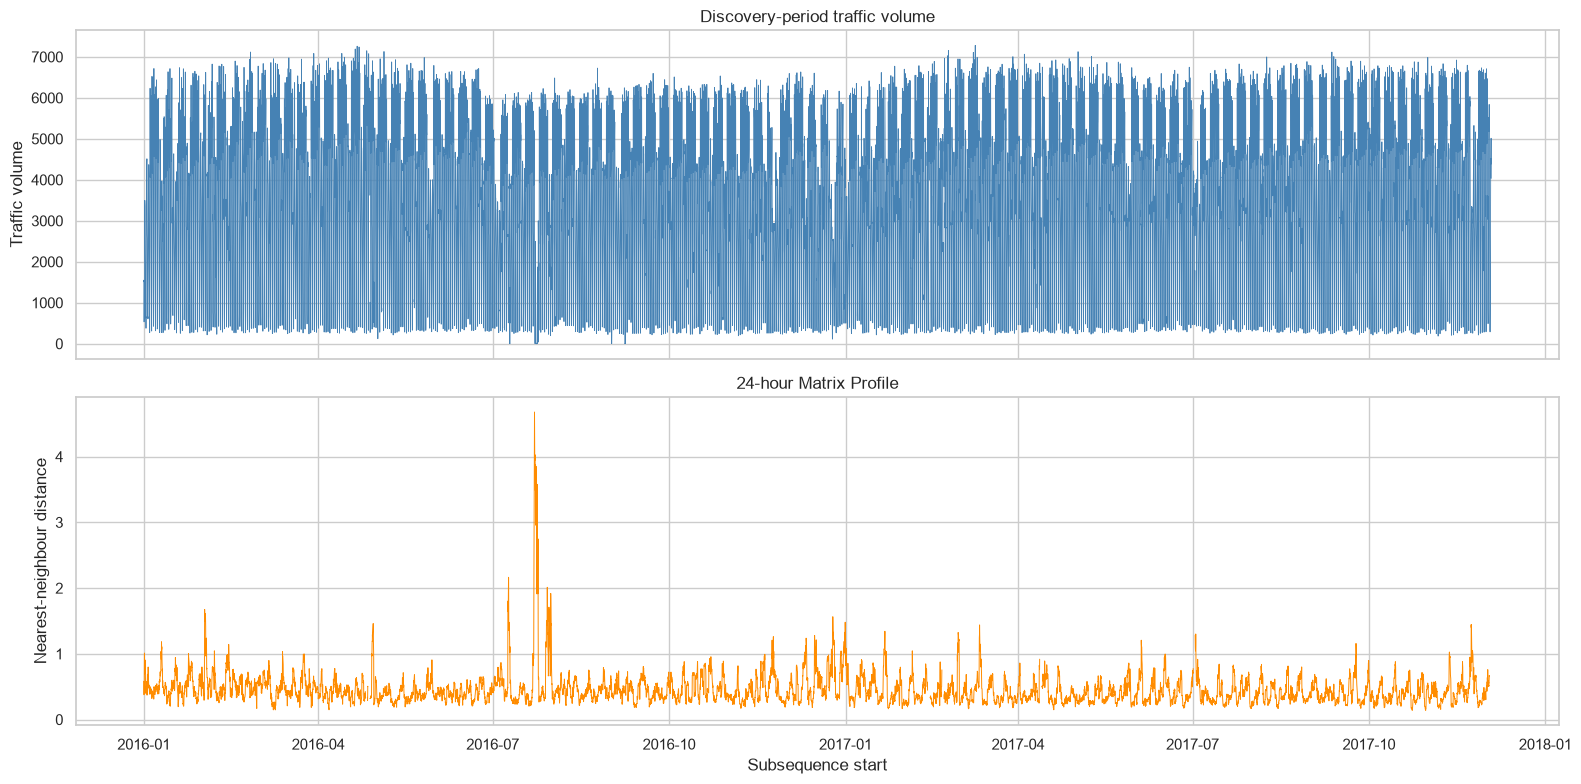

In [14]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(16, 8),
    sharex=True
)

axes[0].plot(
    discovery_df.index,
    discovery_df[
        "traffic_volume_clean"
    ],
    color="steelblue",
    linewidth=0.6
)

axes[0].set_title(
    "Discovery-period traffic volume"
)
axes[0].set_ylabel("Traffic volume")

axes[1].plot(
    profile_times,
    profile_values,
    color="darkorange",
    linewidth=0.7
)

axes[1].set_title(
    "24-hour Matrix Profile"
)
axes[1].set_xlabel("Subsequence start")
axes[1].set_ylabel("Nearest-neighbour distance")

plt.tight_layout()
plt.show()

In [15]:
def select_distinct_motif_pairs(
    profile,
    neighbours,
    window,
    number_of_pairs=5
):
    order = np.argsort(profile)

    excluded = np.zeros(
        len(profile),
        dtype=bool
    )

    selected = []

    for first_index in order:
        if not np.isfinite(
            profile[first_index]
        ):
            continue

        second_index = int(
            neighbours[first_index]
        )

        if (
            second_index < 0
            or second_index >= len(profile)
        ):
            continue

        if (
            excluded[first_index]
            or excluded[second_index]
        ):
            continue

        selected.append({
            "first_index": first_index,
            "second_index": second_index,
            "distance": profile[first_index]
        })

        for index in [
            first_index,
            second_index
        ]:
            lower = max(
                0,
                index - window
            )

            upper = min(
                len(profile),
                index + window + 1
            )

            excluded[lower:upper] = True

        if len(selected) == number_of_pairs:
            break

    return pd.DataFrame(selected)


motif_pairs = select_distinct_motif_pairs(
    profile_values,
    nearest_indices,
    WINDOW,
    number_of_pairs=5
)

motif_pairs

,first_index,second_index,distance
0,15878,16046,0.139847
1,1622,1646,0.147189
2,2319,11391,0.148685
3,13862,14198,0.167076
4,15234,15402,0.170411


In [16]:
def get_window(values, start, window):
    return values[
        start:start + window
    ]


def peak_timestamp(index, values):
    peak_offset = int(
        np.nanargmax(values)
    )

    return index + pd.Timedelta(
        hours=peak_offset
    )


motif_rows = []

for rank, row in motif_pairs.iterrows():
    first_index = int(
        row["first_index"]
    )

    second_index = int(
        row["second_index"]
    )

    first_start = (
        discovery_df.index[first_index]
    )

    second_start = (
        discovery_df.index[second_index]
    )

    first_window = get_window(
        discovery_values,
        first_index,
        WINDOW
    )

    second_window = get_window(
        discovery_values,
        second_index,
        WINDOW
    )

    motif_rows.append({
        "motif_rank": rank + 1,
        "first_start": first_start,
        "second_start": second_start,
        "distance": row["distance"],
        "first_weekday":
            first_start.day_name(),
        "second_weekday":
            second_start.day_name(),
        "first_mean_volume":
            np.mean(first_window),
        "second_mean_volume":
            np.mean(second_window),
        "first_peak_time":
            peak_timestamp(
                first_start,
                first_window
            ),
        "second_peak_time":
            peak_timestamp(
                second_start,
                second_window
            )
    })

motif_summary = pd.DataFrame(
    motif_rows
)

motif_summary.round(3)

,motif_rank,first_start,second_start,distance,first_weekday,second_weekday,first_mean_volume,second_mean_volume,first_peak_time,second_peak_time
0,1,2017-10-23 14:00:00,2017-10-30 14:00:00,0.140,Monday,Monday,3626.250,3608.292,2017-10-23 16:00:00,2017-10-30 16:00:00
1,2,2016-03-08 14:00:00,2016-03-09 14:00:00,0.147,Tuesday,Wednesday,3718.708,3697.375,2016-03-08 16:00:00,2016-03-09 16:00:00
2,3,2016-04-06 15:00:00,2017-04-19 15:00:00,0.149,Wednesday,Wednesday,3736.250,3664.792,2016-04-07 07:00:00,2017-04-19 16:00:00
3,4,2017-07-31 14:00:00,2017-08-14 14:00:00,0.167,Monday,Monday,3617.250,3605.917,2017-08-01 07:00:00,2017-08-15 07:00:00
4,5,2017-09-26 18:00:00,2017-10-03 18:00:00,0.170,Tuesday,Tuesday,3700.292,3672.542,2017-09-27 16:00:00,2017-10-04 16:00:00


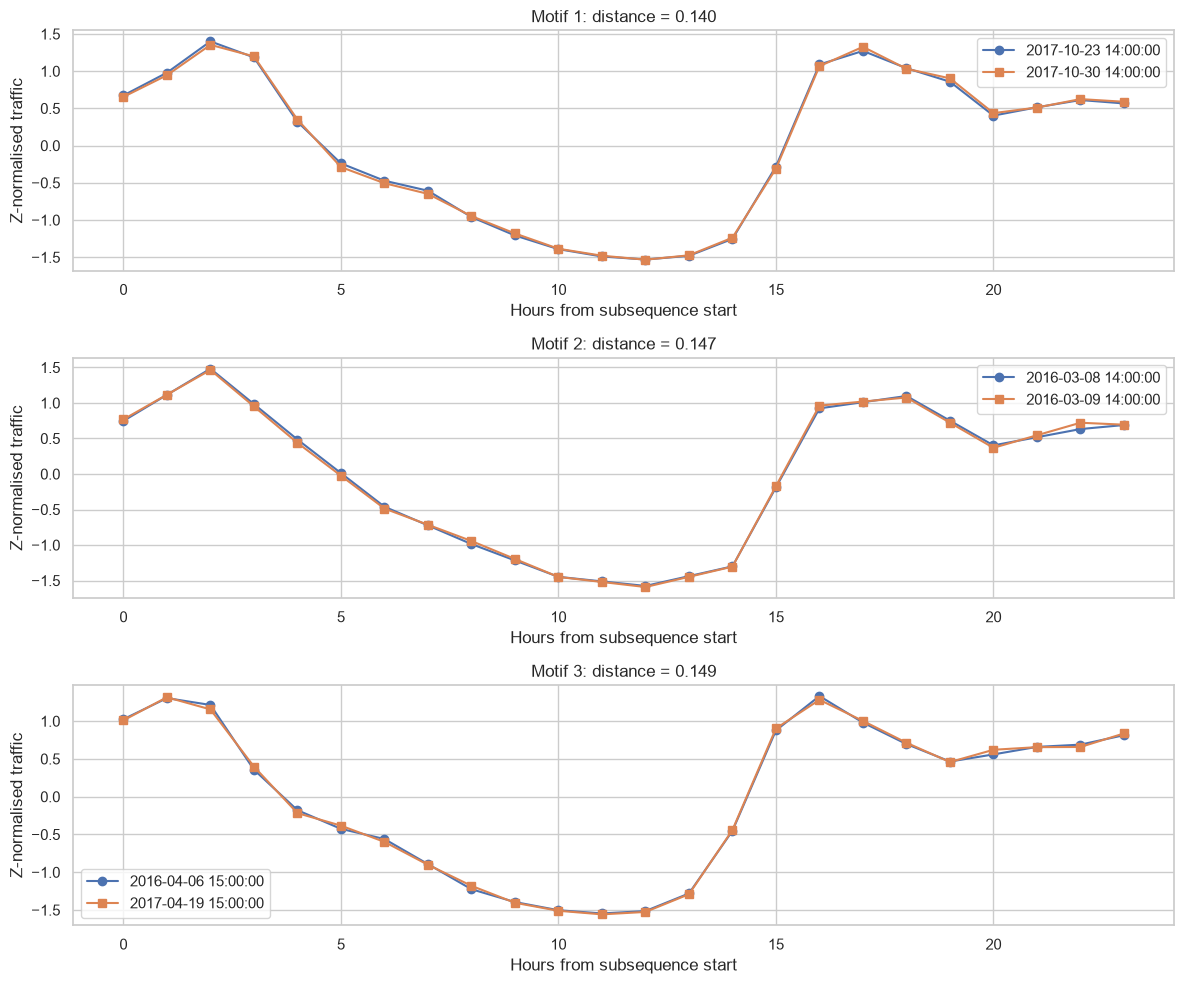

In [17]:
def z_normalise(values):
    values = np.asarray(
        values,
        dtype=float
    )

    standard_deviation = values.std()

    if standard_deviation == 0:
        return np.zeros_like(values)

    return (
        values - values.mean()
    ) / standard_deviation


fig, axes = plt.subplots(
    min(3, len(motif_pairs)),
    1,
    figsize=(12, 10)
)

axes = np.atleast_1d(axes)

for plot_index, ax in enumerate(axes):
    row = motif_pairs.iloc[
        plot_index
    ]

    first_index = int(
        row["first_index"]
    )

    second_index = int(
        row["second_index"]
    )

    first_window = get_window(
        discovery_values,
        first_index,
        WINDOW
    )

    second_window = get_window(
        discovery_values,
        second_index,
        WINDOW
    )

    ax.plot(
        range(WINDOW),
        z_normalise(first_window),
        marker="o",
        label=str(
            discovery_df.index[
                first_index
            ]
        )
    )

    ax.plot(
        range(WINDOW),
        z_normalise(second_window),
        marker="s",
        label=str(
            discovery_df.index[
                second_index
            ]
        )
    )

    ax.set_title(
        f"Motif {plot_index + 1}: "
        f"distance = {row['distance']:.3f}"
    )

    ax.set_xlabel(
        "Hours from subsequence start"
    )

    ax.set_ylabel(
        "Z-normalised traffic"
    )

    ax.legend()

plt.tight_layout()
plt.show()

## Motif-discovery findings

- Window length: **24 hours**
- Discovery-period observations: **16,867**
- Candidate subsequences: **16,844**
- Finite Matrix Profile values: **16,688**
- Minimum motif distance: **0.1398**
- Median Matrix Profile distance: **0.4114**
- Matrix Profile runtime: **0.2712 seconds**
- Distinct motif pairs selected: **5**

The strongest motif connected the 24-hour periods beginning at **23 October 2017 14:00** and **30 October 2017 14:00**. Both periods began on a Monday and had a z-normalised distance of **0.1398**, indicating extremely similar traffic shapes.

Both sequences began with relatively high afternoon traffic, reached an evening peak at approximately **16:00**, declined through the evening, and reached their lowest level during the night. Traffic then increased rapidly during the following morning commute, reached another peak at approximately **07:00**, and remained moderately high during the late morning.

The remaining motif pairs mainly represented repeated weekday commuting cycles:

- **8 March and 9 March 2016**
- **6 April 2016 and 19 April 2017**
- **31 July and 14 August 2017**
- **26 September and 3 October 2017**

Four of the five pairs connected periods beginning on the same weekday. The second motif connected a Tuesday pattern with a Wednesday pattern, showing that similar commuting shapes can also occur on different working days.

The raw mean volumes of the strongest pair were also similar: **3,626.250** and **3,608.292 vehicles per hour**. Across all five pairs, corresponding mean volumes differed by less than approximately **2%**.

However, raw-volume similarity is not required by the method. The Matrix Profile uses z-normalised distance, so it primarily measures whether two subsequences have the same shape rather than whether they contain exactly the same number of vehicles.

In [18]:
finite_profile = profile_values[
    np.isfinite(profile_values)
]

MATCH_THRESHOLD = np.quantile(
    finite_profile,
    0.10
)

print(
    "Future-match threshold:",
    round(MATCH_THRESHOLD, 4)
)

Future-match threshold: 0.2575


In [19]:
validation_rows = []
best_future_pairs = []

for rank, row in motif_pairs.iterrows():
    discovery_index = int(
        row["first_index"]
    )

    query = get_window(
        discovery_values,
        discovery_index,
        WINDOW
    )

    future_matches = np.asarray(
        stumpy.match(
            query,
            test_values,
            max_distance=MATCH_THRESHOLD,
            max_matches=20
        )
    )

    best_match = np.asarray(
        stumpy.match(
            query,
            test_values,
            max_distance=np.inf,
            max_matches=1
        )
    )

    if best_match.size > 0:
        best_distance = float(
            best_match[0, 0]
        )

        best_index = int(
            best_match[0, 1]
        )

        best_start = (
            test_df.index[best_index]
        )

        best_future_pairs.append({
            "motif_rank": rank + 1,
            "query": query,
            "future_index": best_index
        })
    else:
        best_distance = np.nan
        best_index = -1
        best_start = pd.NaT

    validation_rows.append({
        "motif_rank": rank + 1,
        "discovery_start":
            discovery_df.index[
                discovery_index
            ],
        "discovery_pair_distance":
            row["distance"],
        "future_best_start":
            best_start,
        "future_best_distance":
            best_distance,
        "future_matches_below_threshold":
            len(future_matches),
        "future_distance_to_threshold":
            best_distance / MATCH_THRESHOLD
    })

future_validation = pd.DataFrame(
    validation_rows
)

future_validation.round(4)

,motif_rank,discovery_start,discovery_pair_distance,future_best_start,future_best_distance,future_matches_below_threshold,future_distance_to_threshold
0,1,2017-10-23 14:00:00,0.1398,2018-04-23 14:00:00,0.2345,2,0.9109
1,2,2016-03-08 14:00:00,0.1472,2018-04-30 14:00:00,0.4304,0,1.6719
2,3,2016-04-06 15:00:00,0.1487,2018-03-21 15:00:00,0.2866,0,1.1130
3,4,2017-07-31 14:00:00,0.1671,2018-08-13 14:00:00,0.2382,3,0.9251
4,5,2017-09-26 18:00:00,0.1704,2018-05-01 18:00:00,0.2702,0,1.0495


In [20]:
def complete_window_starts(
    values,
    window
):
    return np.array([
        start
        for start in range(
            len(values) - window + 1
        )
        if np.isfinite(
            values[
                start:start + window
            ]
        ).all()
    ])


valid_discovery_starts = (
    complete_window_starts(
        discovery_values,
        WINDOW
    )
)

rng = np.random.default_rng(SEED)

random_starts = rng.choice(
    valid_discovery_starts,
    size=min(
        30,
        len(valid_discovery_starts)
    ),
    replace=False
)

random_future_distances = []

for start in random_starts:
    random_query = get_window(
        discovery_values,
        start,
        WINDOW
    )

    match = np.asarray(
        stumpy.match(
            random_query,
            test_values,
            max_distance=np.inf,
            max_matches=1
        )
    )

    if match.size > 0:
        random_future_distances.append(
            float(match[0, 0])
        )

random_future_distances = np.array(
    random_future_distances
)

baseline_summary = pd.Series({
    "motif_median_future_distance":
        future_validation[
            "future_best_distance"
        ].median(),
    "random_median_future_distance":
        np.median(
            random_future_distances
        ),
    "motif_mean_future_distance":
        future_validation[
            "future_best_distance"
        ].mean(),
    "random_mean_future_distance":
        np.mean(
            random_future_distances
        ),
    "motifs_passing_threshold":
        (
            future_validation[
                "future_best_distance"
            ]
            <= MATCH_THRESHOLD
        ).sum()
})

baseline_summary.round(4)

motif_median_future_distance     0.2702
random_median_future_distance    0.5166
motif_mean_future_distance       0.2920
random_mean_future_distance      0.5531
motifs_passing_threshold         2.0000
dtype: float64

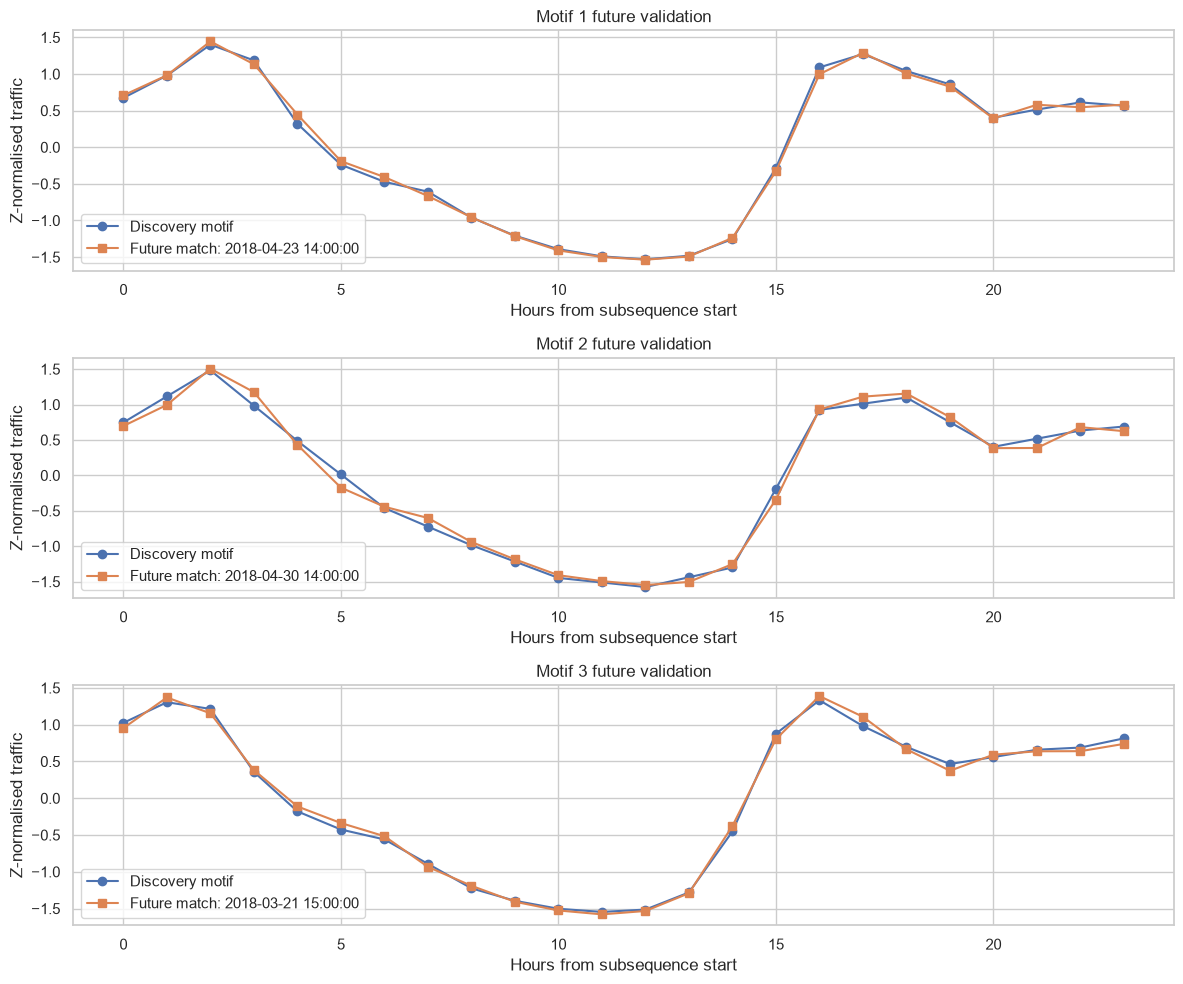

In [21]:
number_of_plots = min(
    3,
    len(best_future_pairs)
)

fig, axes = plt.subplots(
    number_of_plots,
    1,
    figsize=(12, 10)
)

axes = np.atleast_1d(axes)

for ax, pair in zip(
    axes,
    best_future_pairs[
        :number_of_plots
    ]
):
    future_window = get_window(
        test_values,
        pair["future_index"],
        WINDOW
    )

    future_start = test_df.index[
        pair["future_index"]
    ]

    ax.plot(
        range(WINDOW),
        z_normalise(pair["query"]),
        marker="o",
        label="Discovery motif"
    )

    ax.plot(
        range(WINDOW),
        z_normalise(future_window),
        marker="s",
        label=f"Future match: {future_start}"
    )

    ax.set_title(
        f"Motif {pair['motif_rank']} "
        "future validation"
    )

    ax.set_xlabel(
        "Hours from subsequence start"
    )

    ax.set_ylabel(
        "Z-normalised traffic"
    )

    ax.legend()

plt.tight_layout()
plt.show()

## Chronological validation

- Discovery period: **1 January 2016 to 3 December 2017 18:00**
- Test period: **3 December 2017 19:00 to 30 September 2018**
- Match-distance threshold: **0.2575**
- Motifs evaluated: **5**
- Motifs passing the future threshold: **2**
- Median motif future distance: **0.2702**
- Median random-pattern future distance: **0.5166**
- Mean motif future distance: **0.2920**
- Mean random-pattern future distance: **0.5531**

The match threshold was defined as the **10th percentile of the finite discovery-period Matrix Profile values**. It is therefore a deliberately strict, data-derived similarity rule rather than a universally accepted cutoff.

Two of the five motifs had future matches below this threshold. Therefore, the motifs showed **partial rather than complete chronological generalisation**.

The strongest future match connected the discovery sequence beginning at **23 October 2017 14:00** with the test sequence beginning at **23 April 2018 14:00**. Its distance was **0.2345**, which was below the threshold of **0.2575**.

The fourth motif also passed the threshold. Its discovery sequence began at **31 July 2017 14:00**, and its best future match began at **13 August 2018 14:00**, with a distance of **0.2382**.

The median future distance for the selected motifs was approximately **48% lower** than the median distance for 30 randomly selected historical patterns. Thus, even though only two motifs passed the strict threshold, the motif patterns were generally more reproducible in future data than arbitrary historical sequences.

These results suggest that several weekday commuting shapes recur across different months and seasons. However, not every historically strong motif remained equally stable in the later period.

In [22]:
robustness_series = (
    discovery_df[
        "traffic_volume_clean"
    ]
    .iloc[-180 * 24:]
    .to_numpy(dtype=np.float64)
)

window_rows = []

for window in [12, 24, 48]:
    start_time = time.perf_counter()

    profile = stumpy.stump(
        robustness_series,
        m=window
    )

    runtime = (
        time.perf_counter()
        - start_time
    )

    distances = np.asarray(
        profile[:, 0],
        dtype=float
    )

    finite_distances = distances[
        np.isfinite(distances)
    ]

    window_rows.append({
        "window_hours": window,
        "subsequences": len(distances),
        "finite_percentage":
            100
            * len(finite_distances)
            / len(distances),
        "minimum_distance":
            np.min(finite_distances),
        "distance_p10":
            np.quantile(
                finite_distances,
                0.10
            ),
        "median_distance":
            np.median(
                finite_distances
            ),
        "runtime_seconds": runtime
    })

window_robustness = pd.DataFrame(
    window_rows
)

window_robustness.round(4)

,window_hours,subsequences,finite_percentage,minimum_distance,distance_p10,median_distance,runtime_seconds
0,12,4309,99.7215,0.0310,0.1008,0.2411,0.0461
1,24,4297,99.4415,0.1398,0.2551,0.4070,0.0507
2,48,4273,98.8767,0.3274,0.5209,0.7720,0.0396


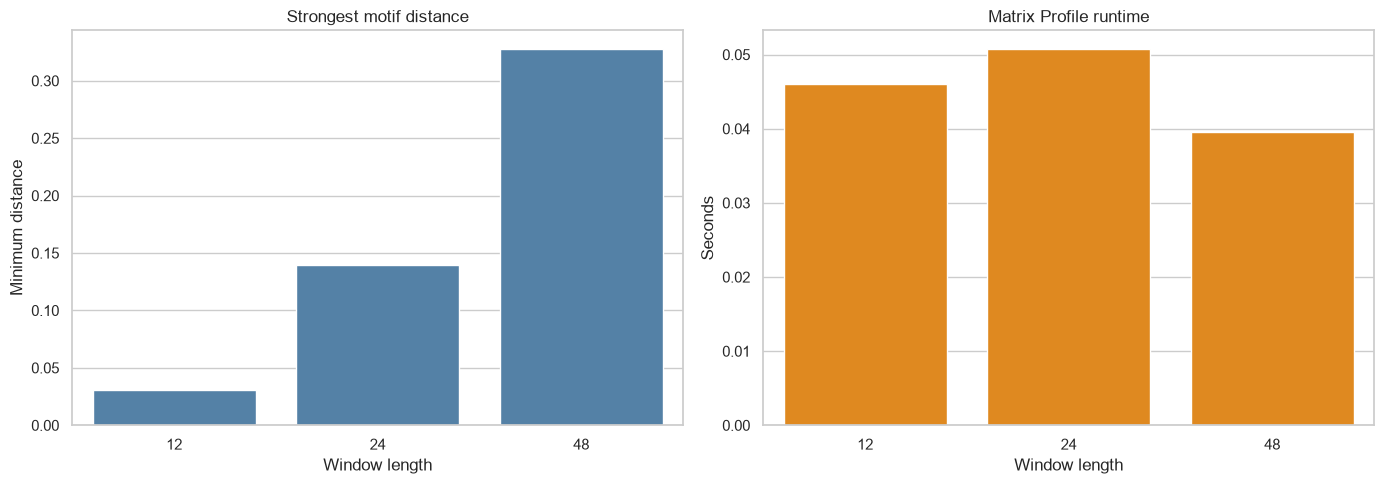

In [23]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.barplot(
    data=window_robustness,
    x="window_hours",
    y="minimum_distance",
    color="steelblue",
    ax=axes[0]
)

axes[0].set_title(
    "Strongest motif distance"
)
axes[0].set_xlabel("Window length")
axes[0].set_ylabel("Minimum distance")

sns.barplot(
    data=window_robustness,
    x="window_hours",
    y="runtime_seconds",
    color="darkorange",
    ax=axes[1]
)

axes[1].set_title(
    "Matrix Profile runtime"
)
axes[1].set_xlabel("Window length")
axes[1].set_ylabel("Seconds")

plt.tight_layout()
plt.show()

## Window-length robustness

| Window | Subsequences | Finite subsequences | Finite percentage | Minimum distance | Median distance | Runtime |
|---:|---:|---:|---:|---:|---:|---:|
| 12 hours | 4,309 | 4,297 | 99.72% | 0.0310 | 0.2411 | 0.0461 s |
| 24 hours | 4,297 | 4,273 | 99.44% | 0.1398 | 0.4070 | 0.0507 s |
| 48 hours | 4,273 | 4,225 | 98.88% | 0.3274 | 0.7720 | 0.0396 s |

The **12-hour window** captured partial-day patterns, such as an overnight-to-morning transition or an afternoon-to-evening decline. It produced the smallest distances because shorter sequences contain fewer values that must match.

The **24-hour window** captured a complete daily traffic cycle, including afternoon traffic, the overnight decline and the following morning commute. This makes the motifs easier to interpret operationally as recurring traffic-day shapes.

The **48-hour window** captured two-day patterns and transitions between consecutive weekdays or between weekdays and weekends. These longer patterns were more difficult to match closely.

Raw z-normalised Euclidean distances naturally tend to increase with window length because more hourly positions contribute to the distance. Therefore, the minimum distances for different window lengths should not be treated as directly comparable measures of model quality.

The runtime differences were only a few milliseconds and should not be interpreted as meaningful performance differences. The **24-hour window** was retained because it provides the clearest practical interpretation, not because it produced the smallest raw distance.

## Final interpretation

The Matrix Profile analysis selected **five distinct recurring 24-hour motif pairs** in westbound Interstate 94 traffic.

The strongest motif connected the sequences beginning at **23 October 2017 14:00** and **30 October 2017 14:00**. It had a nearest-neighbour distance of **0.1398**.

The strongest motifs represented highly consistent weekday commuting shapes. They generally included:

1. relatively high afternoon traffic;
2. an evening peak;
3. a gradual overnight decline;
4. an early-morning minimum;
5. a sharp morning commuting increase;
6. a morning peak followed by sustained daytime traffic.

Chronological validation found that **2 of the 5 motifs** had future matches below the strict distance threshold. The median future-match distance was **0.2702** for motif queries compared with **0.5166** for randomly selected queries. The detected motifs were therefore substantially more reproducible than arbitrary historical patterns, although not every motif remained stable in the later period.

### Practical use

Transport operators could use the motif library to:

- recognise recurring traffic-day shapes;
- retrieve historical periods similar to the current traffic pattern;
- anticipate how traffic may develop during the following hours;
- support staffing and traffic-control planning;
- compare current conditions with previous operational patterns;
- identify days that do not resemble normal commuting behaviour;
- organise historical traffic data without manually assigning labels.

### Limitations

The dataset represents only one westbound traffic station, so these motifs should not automatically be generalised to other roads, directions or cities.

Z-normalisation emphasises shape rather than absolute vehicle counts. Two periods may therefore be classified as similar even when one has consistently higher traffic volume.

The five reported motif pairs were selected as the strongest distinct pairs. The number five was chosen by the analysis code and was not automatically learned as the true number of traffic-pattern types.

The validation threshold was based on the 10th percentile of discovery-period distances. It is a practical heuristic rather than a universal statistical boundary.

The 24-hour window was selected for operational interpretability. Different window lengths reveal different types of recurring behaviour.

Short missing gaps were interpolated. Windows containing the remaining long gaps received non-finite Matrix Profile values and were not eligible to become valid motifs.

Finally, the motifs identify recurring associations in traffic behaviour. They do not prove that weather, holidays or any other contextual variable caused the observed patterns.